# yfinance Library Assignment  

In [4]:
#!pip install yfinance
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [ ]:
# Code Here 
#This is a function which forms a data frmame from the downloaded historical data given time frame is 1d
def download_hdata(symbol, start_date, end_date, timeframe='1d'):
    D = yf.download(symbol, start=start_date, end=end_date, interval=timeframe)
    return D
#Here i have used the previously made function to get reliance data of the year 2025
data = download_hdata("RELIANCE.NS", "2025-01-01", "2025-12-31")
print(data.head())
# Shows first 5 rows

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2025-01-01  1210.793579  1215.800389  1201.226179  1204.448352     5892590
2025-01-02  1231.167725  1233.794938  1209.554328  1210.793626    15486276
2025-01-03  1240.437744  1251.244443  1224.921714  1233.249818    15521102
2025-01-06  1207.571411  1251.194681  1204.597097  1243.213557    14816766
2025-01-07  1230.225708  1233.844481  1210.793549  1211.537128    10070505


### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


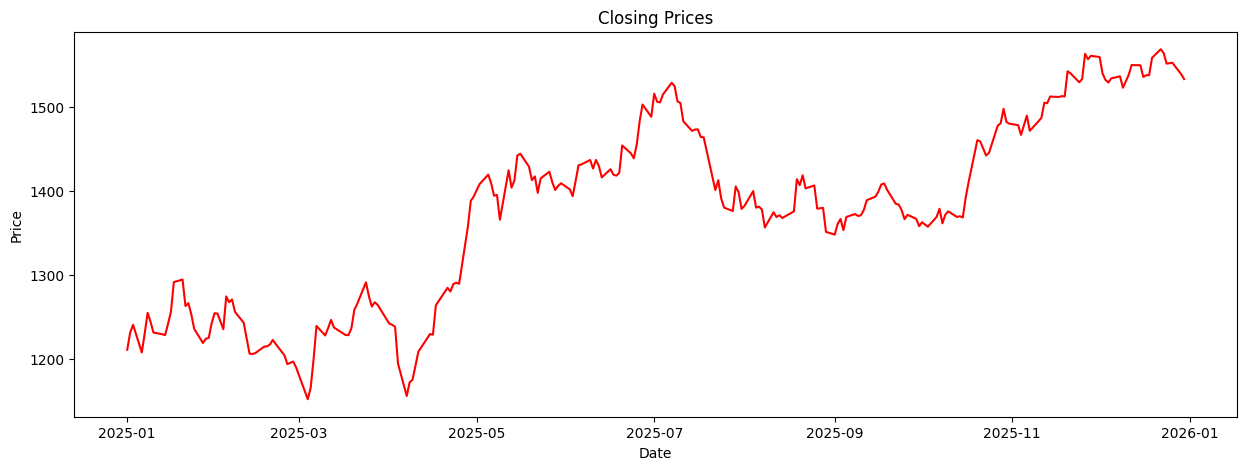

In [30]:
# Code here
# I did make a function which works on the same thing forms a normal line graph of the closing price
def plotclose(data):
    plt.figure(figsize=(15,5))
    plt.plot(data.index, data['Close'], color='red')
    plt.title('Closing Prices')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.show()
#plotting the data i have converted into the data frame
plotclose(data) 

### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


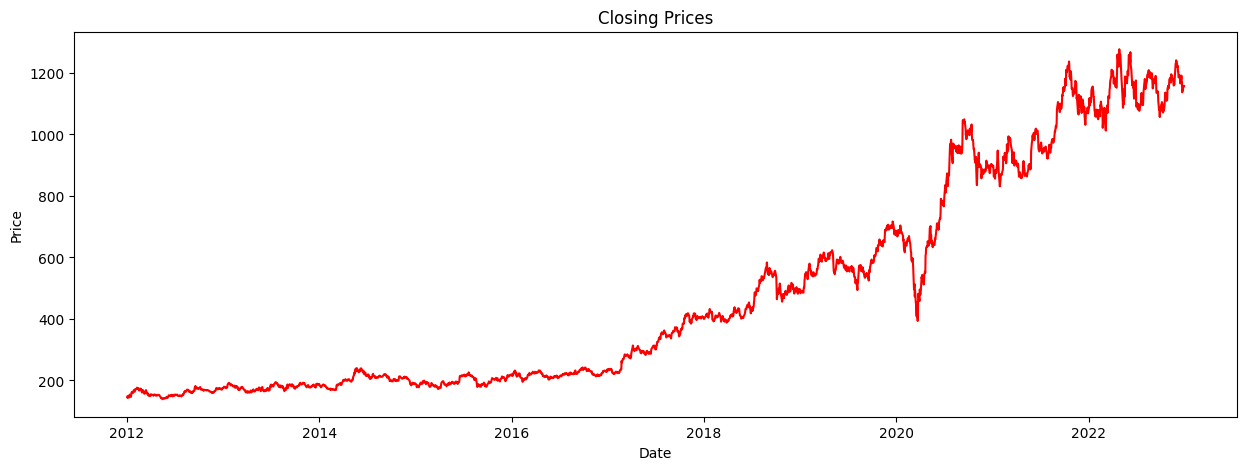

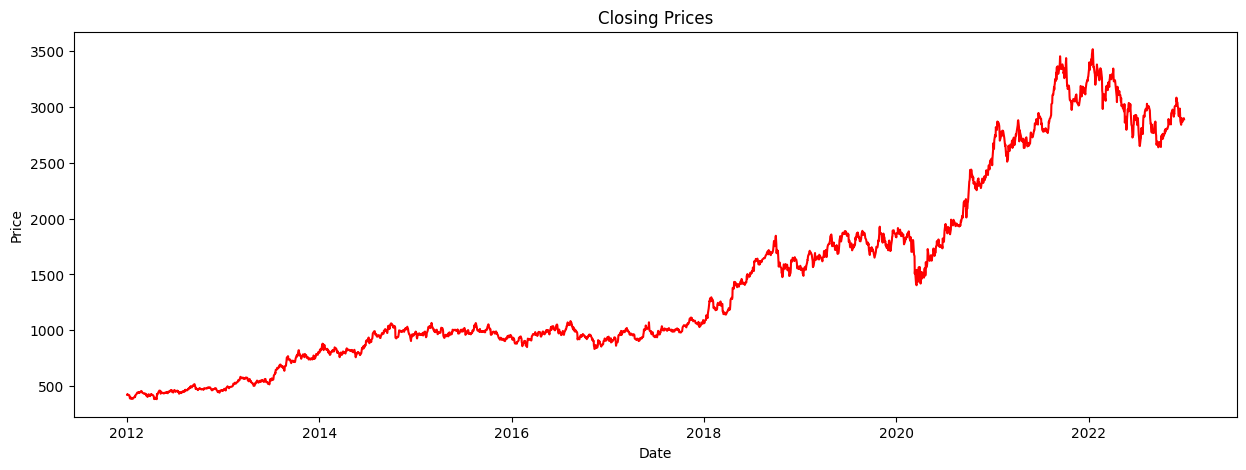

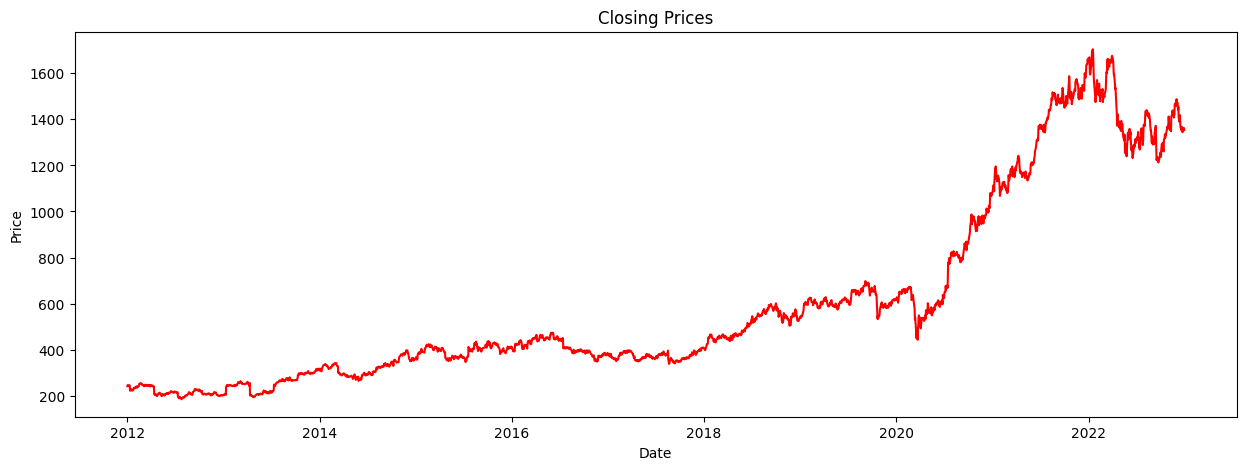

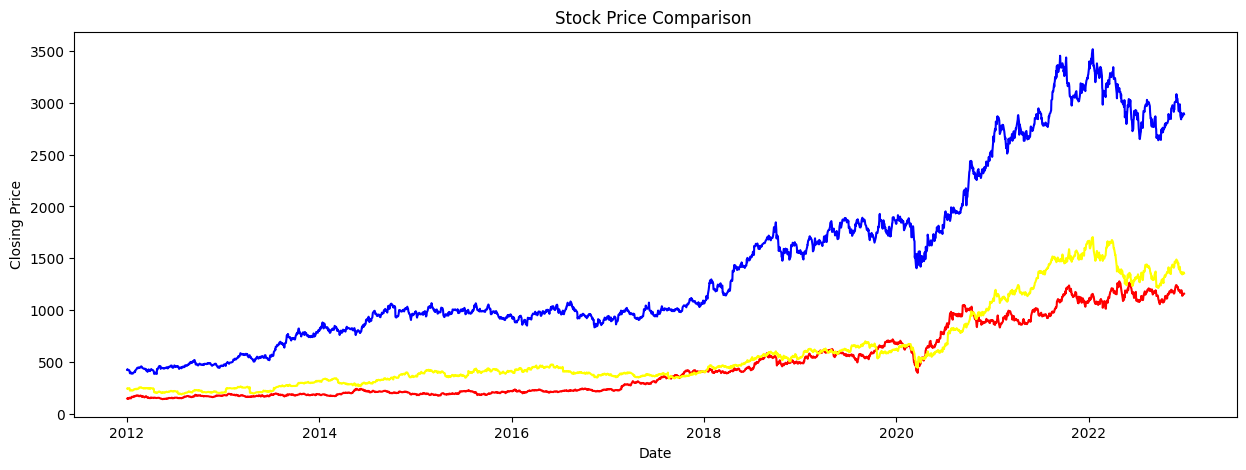

In [31]:
# Code here 
#Making data frames for each stock using previously formed function
reliance = download_hdata("RELIANCE.NS", "2012-01-01", "2022-12-31")
tcs = download_hdata("TCS.NS", "2012-01-01", "2022-12-31")
infosys = download_hdata("INFY.NS", "2012-01-01", "2022-12-31")
#plotting each stock differently using previously made funciton
plotclose(reliance)
plotclose(tcs)
plotclose(infosys)
#Plotting all of them together 
plt.figure(figsize=(15,5))
plt.plot(reliance['Close'], label='Reliance', color='red')
plt.plot(tcs['Close'], label='TCS', color='blue')
plt.plot(infosys['Close'], label='Infosys', color='yellow')
plt.title('Stock Price Comparison ')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

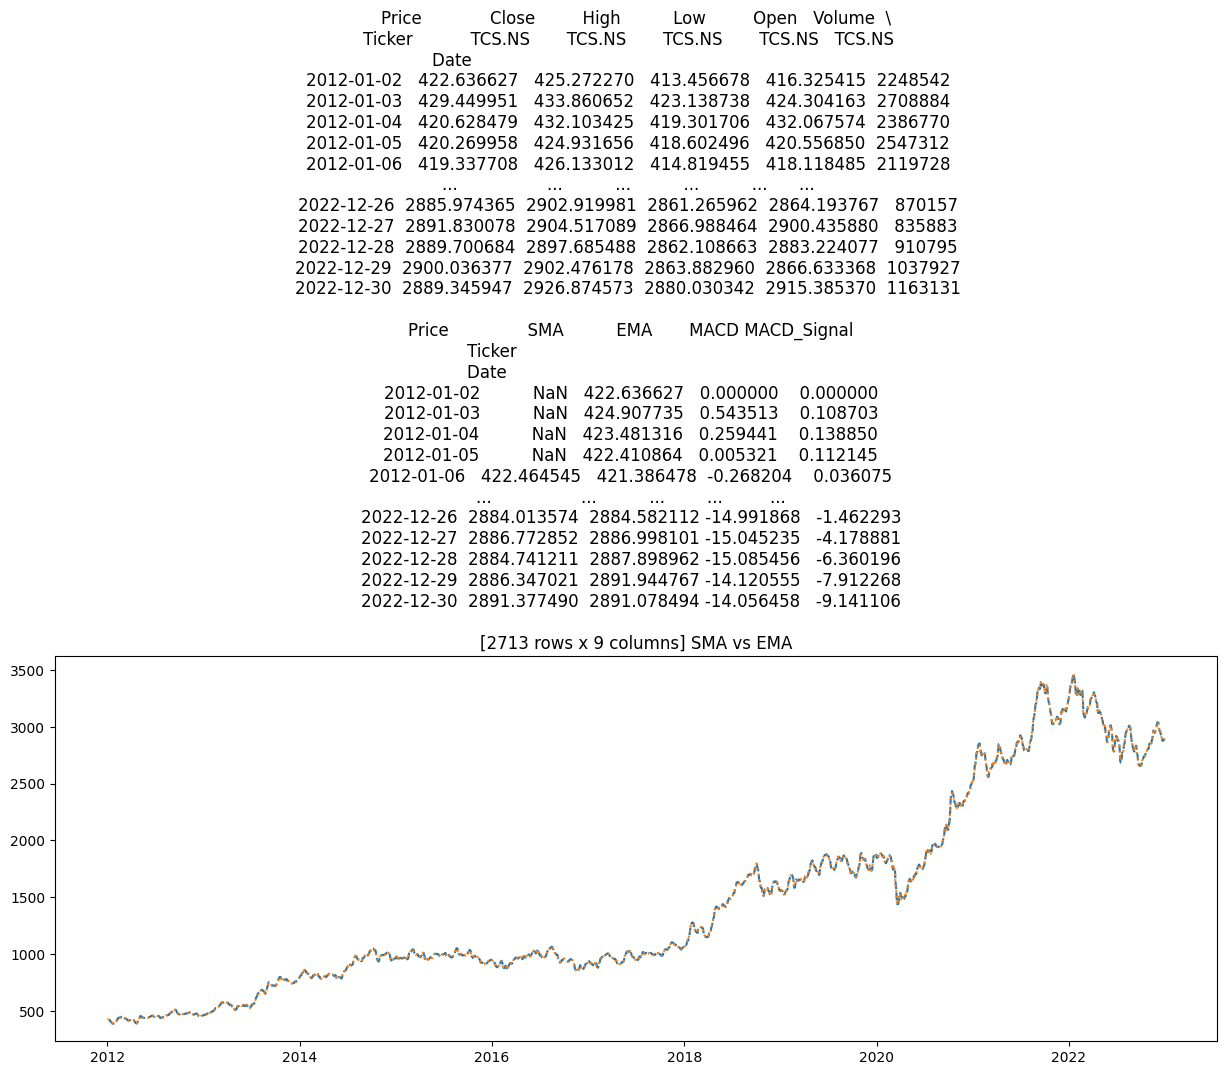

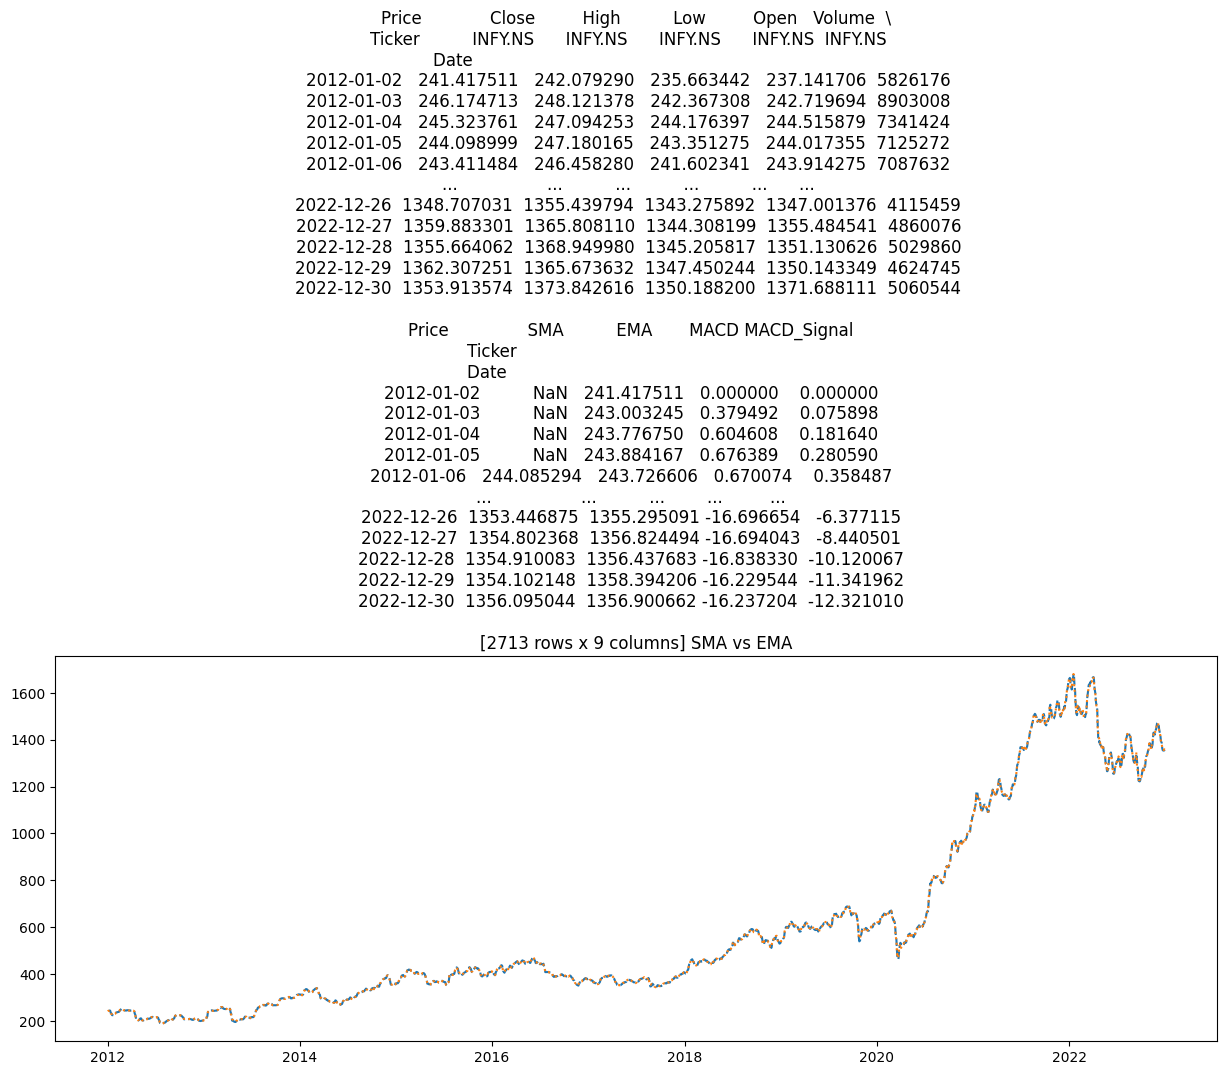

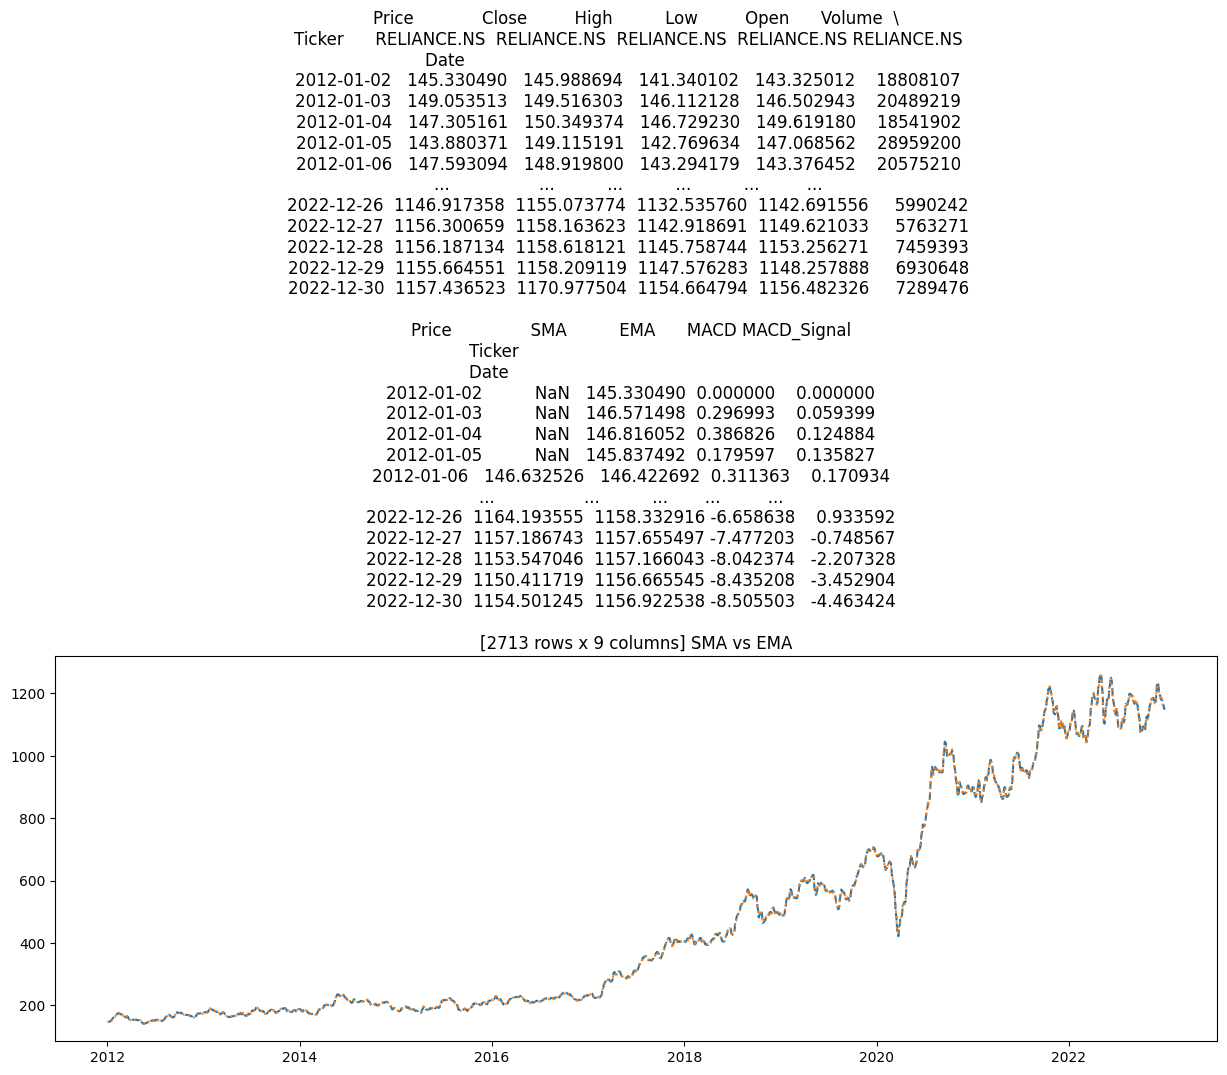

In [24]:
# Code here 
def sma_ema_plot(data):
    data['SMA'] = data['Close'].rolling(window=5).mean()
    data['EMA'] = data['Close'].ewm(span=5, adjust=False).mean()
    #plt.plot(data['Close'], label='Close Price')
    plt.figure(figsize=(15,5))
    plt.plot(data['SMA'], '--',label='5-Day SMA')
    plt.plot(data['EMA'],':' ,label='5-Day EMA')
    plt.title(f'{data} SMA vs EMA')
    plt.show()

sma_ema_plot(tcs)
sma_ema_plot(infosys)
sma_ema_plot(reliance)

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

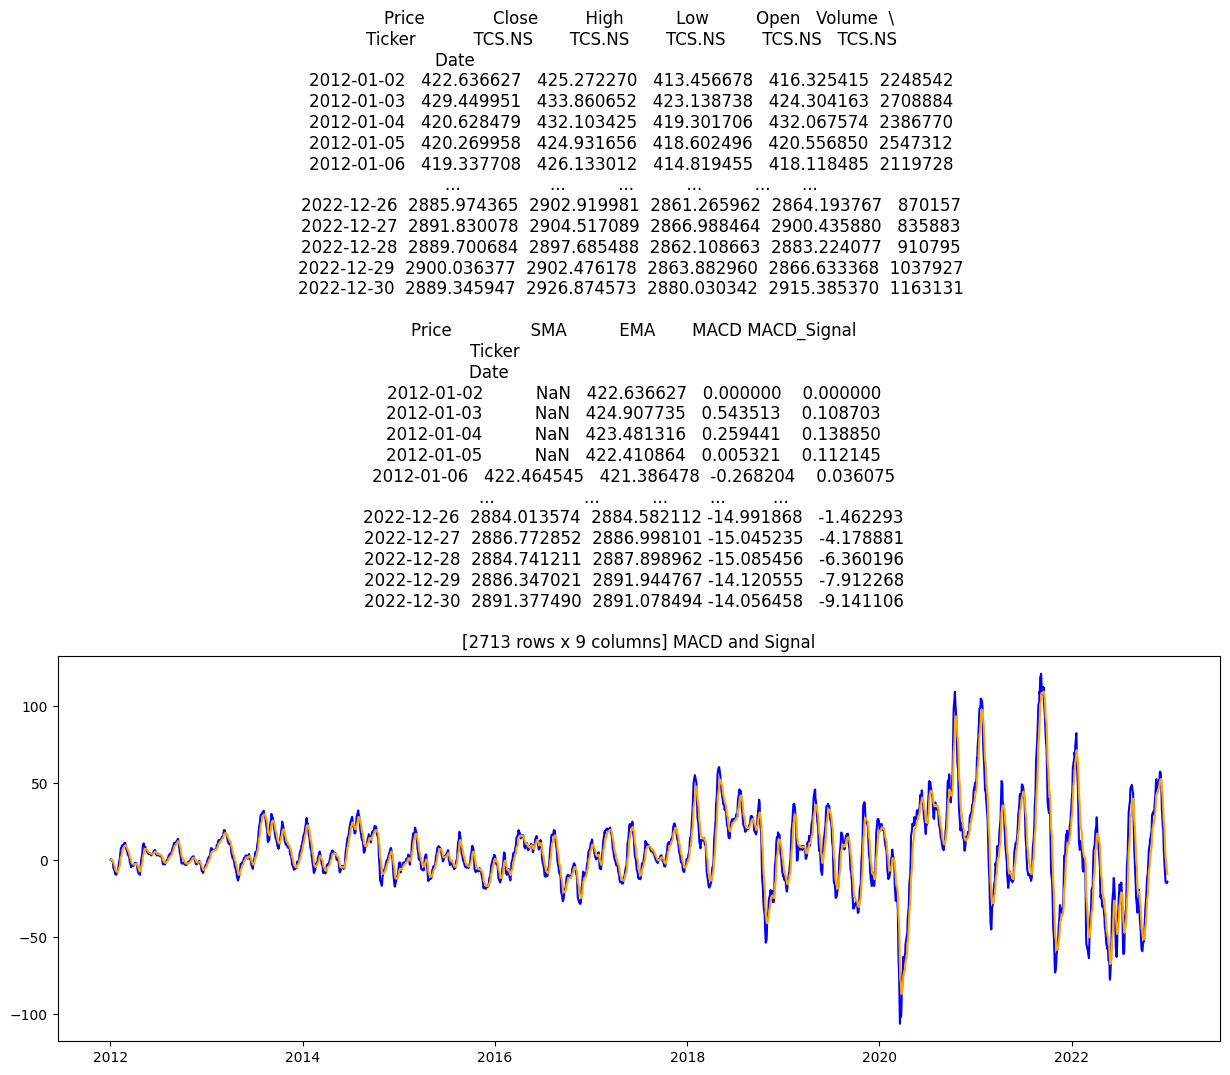

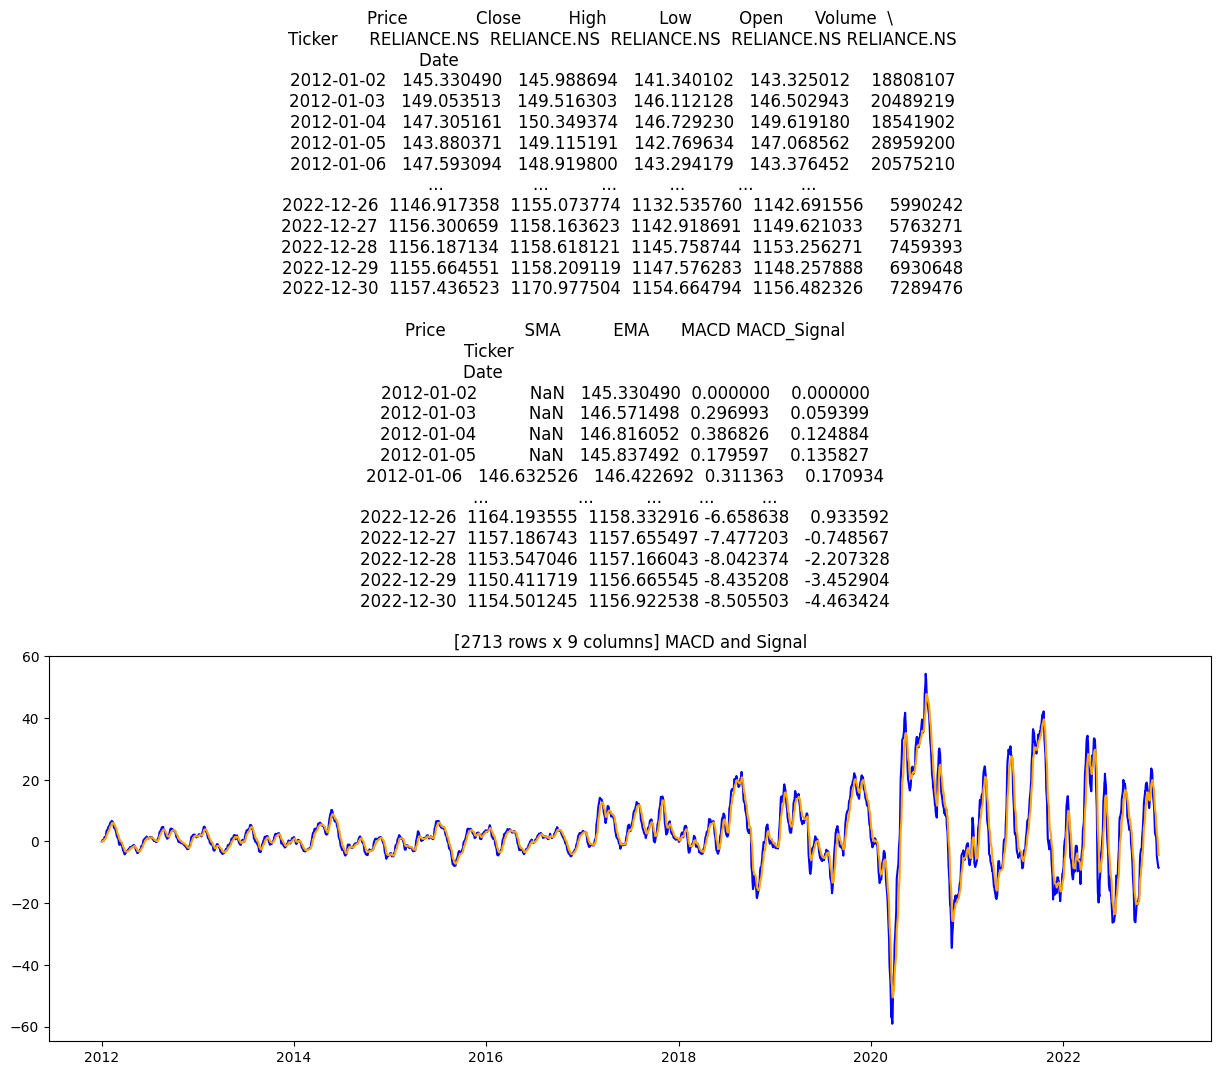

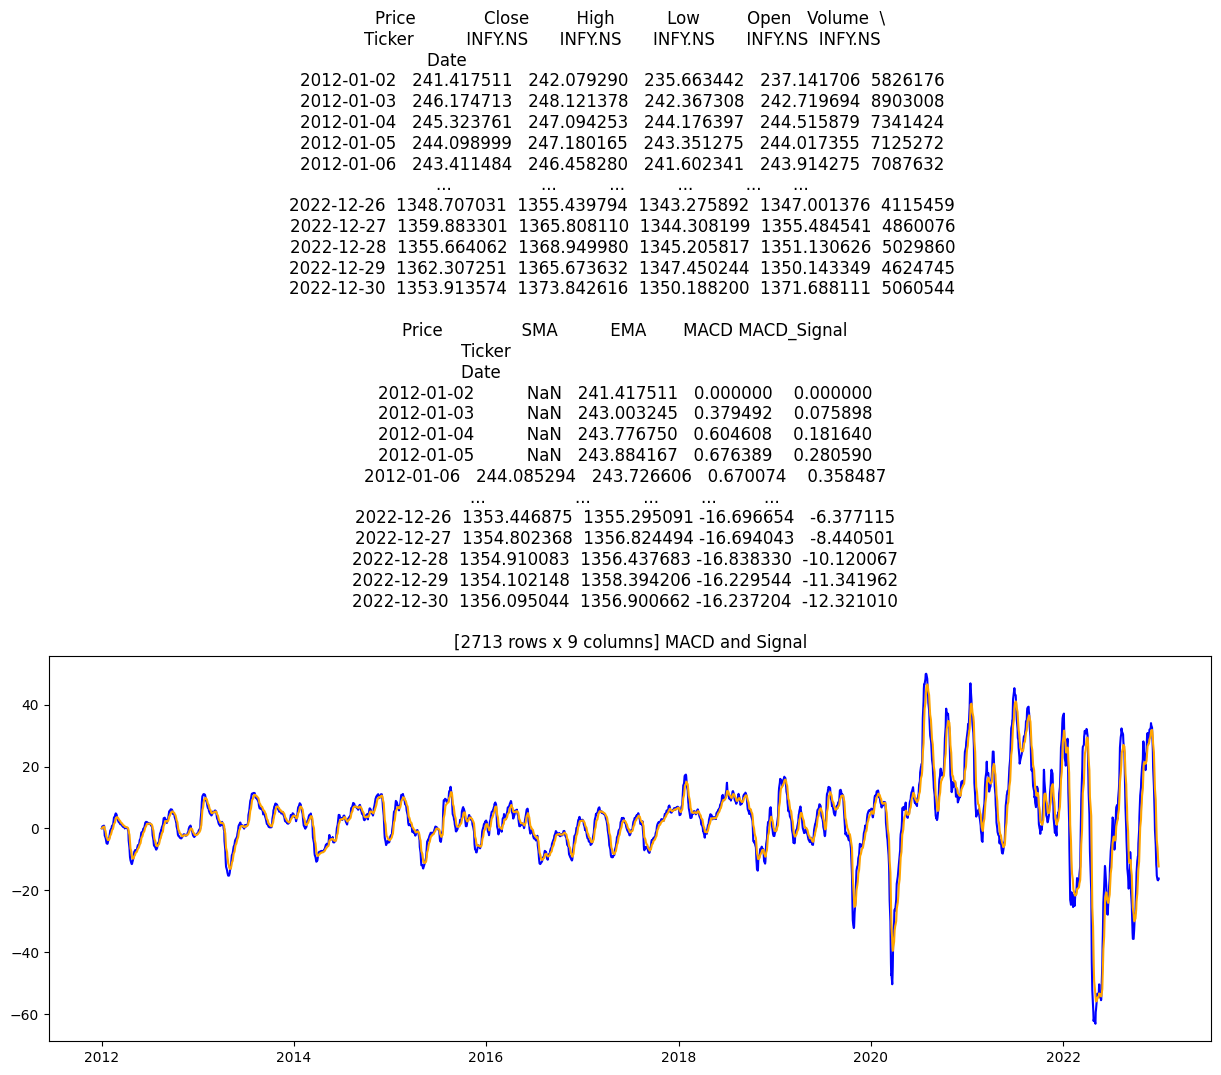

In [23]:
# Code Here
def MACD_plot(data):
    data['MACD']=(data['Close'].ewm(span=12, adjust=False).mean())-(data['Close'].ewm(span=26, adjust=False).mean())
    data['MACD_Signal']=data['MACD'].ewm(span=9, adjust=False).mean()
    plt.figure(figsize=(15,5))
    plt.plot(data['MACD'],color='blue',label='MACD line')
    plt.plot(data['MACD_Signal'],color='orange',label='Signal line')
    plt.title(f'{data} MACD and Signal')
    plt.show()
MACD_plot(tcs)
MACD_plot(reliance)
MACD_plot(infosys)
    

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

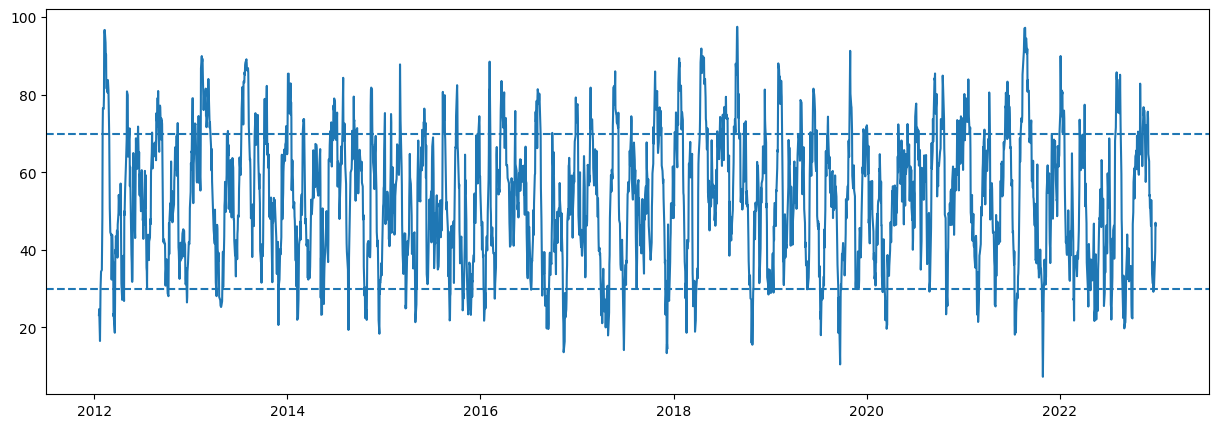

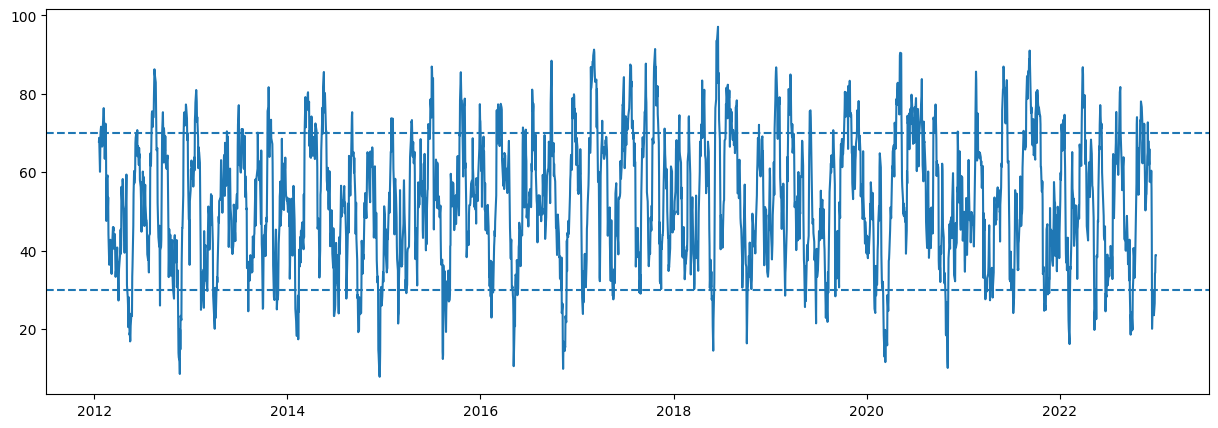

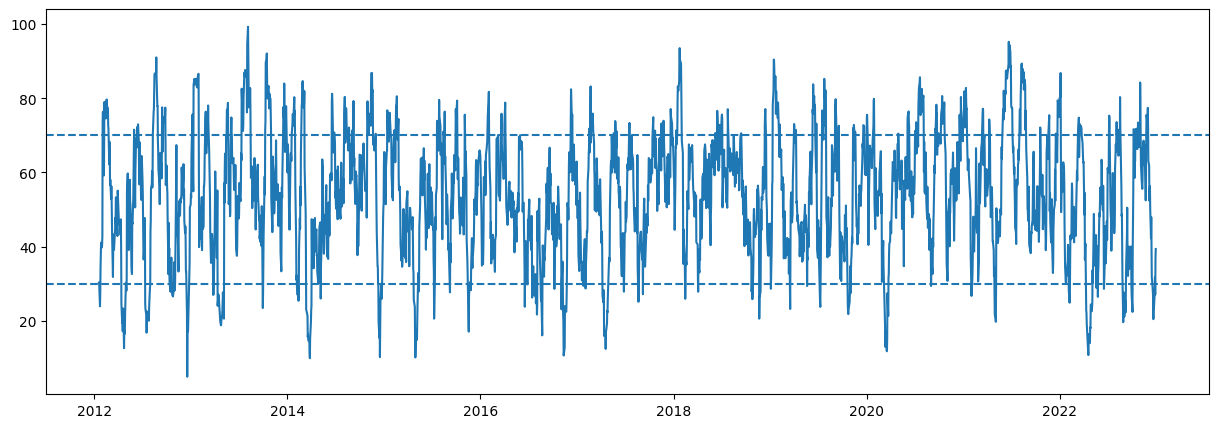

In [28]:
# Code here
def rsi_plot(data):
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    data['RSI'] = rsi
    plt.figure(figsize=(15,5))
    plt.plot(data['RSI'])
    plt.axhline(70, linestyle='--', label='Overbought')
    plt.axhline(30, linestyle='--', label='Oversold')
    plt.show()
    
rsi_plot(tcs)
rsi_plot(reliance)
rsi_plot(infosys)

### Summarize your analysis

In [ ]:
""" Write your answer here """